Quantas frases falam sobre amor?
regressão logistica com penalização
Arvore com parametro oob = false
Tentar excluir colunas que as palavras aparecem pouco

# Tag LOVE

In [9]:
import pandas as pd
import ast
import numpy as np

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf[
    ~df_tfidf["tags"].apply(
        lambda tags: "attributed-no-source" in tags
    )
].copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "love" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())
df_tfidf.shape

tag_love
0    82
1    15
Name: count, dtype: int64


(97, 560)

In [67]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

In [4]:
#modelo = LogisticRegression(
#    max_iter=1000,
#    class_weight="balanced",
#    penalty="l1",
#    solver = "liblinear"
#)

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

modelo = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [62]:

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [69]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]


from sklearn.metrics import f1_score

# grid de thresholds
thresholds = np.arange(0.01, 1.00, 0.001)

melhor_f1 = 0
melhor_threshold = 0

for t in thresholds:

    y_pred = (prob_love >= t).astype(int)

    f1 = f1_score(y, y_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = t

print("Melhor threshold:", melhor_threshold)
print("Melhor F1:", melhor_f1)

C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Us

Melhor threshold: 0.4449999999999996
Melhor F1: 0.5384615384615384


C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Us

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        82
           1       0.64      0.47      0.54        15

    accuracy                           0.88        97
   macro avg       0.77      0.71      0.73        97
weighted avg       0.87      0.88      0.87        97



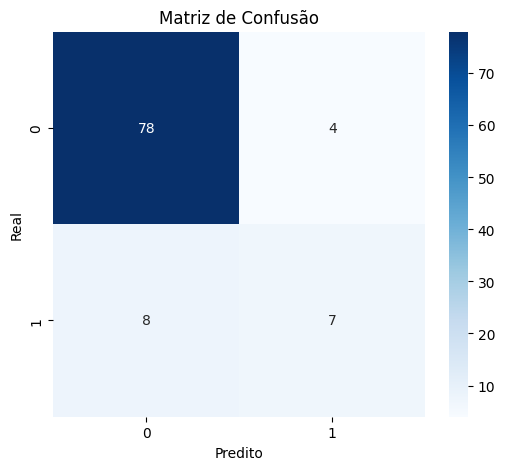

In [70]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= melhor_threshold).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)


cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [71]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_love": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_love",
    ascending=False
).head(60)

,frase,tags,real,probabilidade_love,predicao
49,"“Love does not begin and end the way we seem to think it does. Love is a battle, love is a war; love is a growing up.”",['love'],1,0.830990,1
81,"“A lady's imagination is very rapid; it jumps from admiration to love, from love to matrimony in a moment.”","['humor', 'love', 'romantic', 'women']",1,0.756769,1
35,“All you need is love. But a little chocolate now and then doesn't hurt.”,"['chocolate', 'food', 'humor']",0,0.735844,1
62,"“Remember, we're madly in love, so it's all right to kiss me anytime you feel like it.”",['humor'],0,0.650622,1
17,"“It is not a lack of love, but a lack of friendship that makes unhappy marriages.”","['friendship', 'lack-of-friendship', 'lack-of-love', 'love', 'marriage', 'unhappy-marriage']",1,0.642951,1
33,“Not all of us can do great things. But we can do small things with great love.”,"['misattributed-to-mother-teresa', 'paraphrased']",0,0.625239,1
20,"“I love you without knowing how, or when, or from where. I love you simply, without problems or pride: I love you in this way because I do not know any other way of loving but this, in which there is no I or you, so intimate that your hand upon my chest is my hand, so intimate that when I fall asleep your eyes close.”","['love', 'poetry']",1,0.604917,1
65,"“Do not pity the dead, Harry. Pity the living, and, above all those who live without love.”",['live-death-love'],1,0.601212,1
23,“Anyone who thinks sitting in church can make you a Christian must also think that sitting in a garage can make you a car.”,"['humor', 'religion']",0,0.538791,1
63,"“To love at all is to be vulnerable. Love anything and your heart will be wrung and possibly broken. If you want to make sure of keeping it intact you must give it to no one, not even an animal. Wrap it carefully round with hobbies and little luxuries; avoid all entanglements. Lock it up safe in the casket or coffin of your selfishness. But in that casket, safe, dark, motionless, airless, it will change. It will not be broken; it will become unbreakable, impenetrable, irredeemable. To love is to be vulnerable.”",['love'],1,0.522505,1


In [42]:
resultado.sort_values(
    by="probabilidade_love",
    ascending=False
)[["frase", "probabilidade_love"]].head(10)

,frase,probabilidade_love
49,“Love does not begin and end the way we seem t...,0.527723
20,"“I love you without knowing how, or when, or f...",0.502154
81,“A lady's imagination is very rapid; it jumps ...,0.491786
23,“Anyone who thinks sitting in church can make ...,0.456606
17,"“It is not a lack of love, but a lack of frien...",0.456564
35,“All you need is love. But a little chocolate ...,0.452433
91,“I'm the one that's got to die when it's time ...,0.444704
43,"“If you can make a woman laugh, you can make h...",0.442753
62,"“Remember, we're madly in love, so it's all ri...",0.430989
66,“There is nothing to writing. All you do is si...,0.429108


# Tag INSPIRATIONAL

In [16]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf[
    ~df_tfidf["tags"].apply(
        lambda tags: "attributed-no-source" in tags
    )
].copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "inspirational" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())
df_tfidf.shape

tag_love
0    84
1    13
Name: count, dtype: int64


(97, 560)

In [4]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

modelo = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]


from sklearn.metrics import f1_score

# grid de thresholds
thresholds = np.arange(0.01, 1.00, 0.001)

melhor_f1 = 0
melhor_threshold = 0

for t in thresholds:

    y_pred = (prob_love >= t).astype(int)

    f1 = f1_score(y, y_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = t

print("Melhor threshold:", melhor_threshold)
print("Melhor F1:", melhor_f1)

Melhor threshold: 0.43899999999999967
Melhor F1: 0.5454545454545454


              precision    recall  f1-score   support

           0       0.92      0.94      0.93        83
           1       0.58      0.50      0.54        14

    accuracy                           0.88        97
   macro avg       0.75      0.72      0.73        97
weighted avg       0.87      0.88      0.87        97



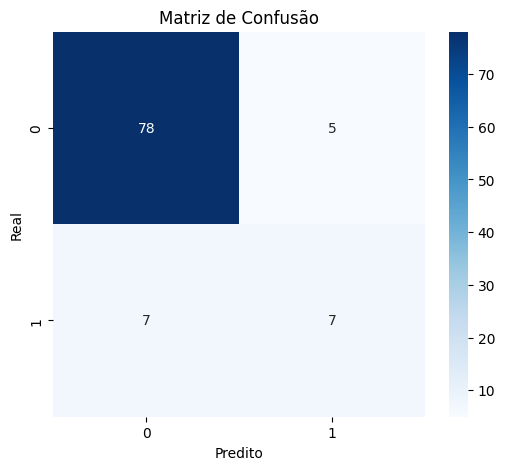

In [22]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= 0.419).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)


cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [20]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_love": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_love",
    ascending=False
).head(60)

,frase,tags,real,probabilidade_love,predicao
59,“Life isn't about finding yourself. Life is about creating yourself.”,"['inspirational', 'life', 'yourself']",1,0.692123,1
6,“It is better to be hated for what you are than to be loved for what you are not.”,"['life', 'love']",1,0.499185,1
99,"“... a mind needs books as a sword needs a whetstone, if it is to keep its edge.”","['books', 'mind']",0,0.461843,1
19,“Life is what happens to us while we are making other plans.”,"['fate', 'life', 'misattributed-john-lennon', 'planning', 'plans']",1,0.456088,1
91,"“I'm the one that's got to die when it's time for me to die, so let me live my life the way I want to.”","['death', 'life']",1,0.455394,1
32,"“The truth is, everyone is going to hurt you. You just got to find the ones worth suffering for.”",['friendship'],0,0.446247,1
44,"“Life is like riding a bicycle. To keep your balance, you must keep moving.”","['life', 'simile']",1,0.443657,1
18,"“Good friends, good books, and a sleepy conscience: this is the ideal life.”","['books', 'contentment', 'friends', 'friendship', 'life']",1,0.441493,1
37,“Any fool can know. The point is to understand.”,"['knowledge', 'learning', 'understanding', 'wisdom']",0,0.438608,0
70,“If I had a flower for every time I thought of you...I could walk through my garden forever.”,"['friendship', 'love']",0,0.435615,0


# Tag LIFE

In [72]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf[
    ~df_tfidf["tags"].apply(
        lambda tags: "attributed-no-source" in tags
    )
].copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "life" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())
df_tfidf.shape

tag_love
0    83
1    14
Name: count, dtype: int64


(97, 560)

In [73]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

modelo = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [45]:

modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [75]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]


from sklearn.metrics import f1_score

# grid de thresholds
thresholds = np.arange(0.01, 1.00, 0.001)

melhor_f1 = 0
melhor_threshold = 0

for t in thresholds:

    y_pred = (prob_love >= t).astype(int)

    f1 = f1_score(y, y_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = t

print("Melhor threshold:", melhor_threshold)
print("Melhor F1:", melhor_f1)

C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Us

Melhor threshold: 0.3869999999999997
Melhor F1: 0.6666666666666666


C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\isabe\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Us

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        83
           1       0.80      0.57      0.67        14

    accuracy                           0.92        97
   macro avg       0.87      0.77      0.81        97
weighted avg       0.91      0.92      0.91        97



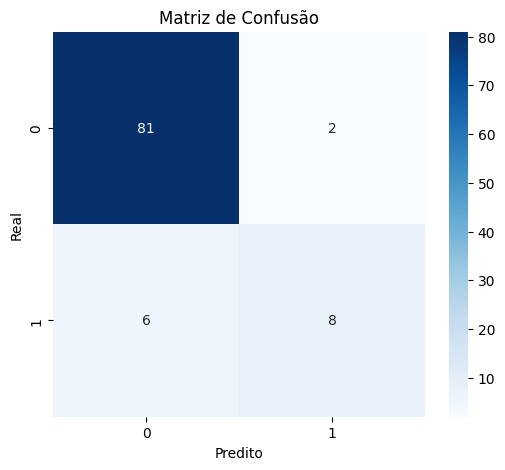

In [76]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= 0.387).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)


cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [77]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_love": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_love",
    ascending=False
).head(60)

,frase,tags,real,probabilidade_love,predicao
59,“Life isn't about finding yourself. Life is about creating yourself.”,"['inspirational', 'life', 'yourself']",1,0.999182,1
19,“Life is what happens to us while we are making other plans.”,"['fate', 'life', 'misattributed-john-lennon', 'planning', 'plans']",1,0.862867,1
18,"“Good friends, good books, and a sleepy conscience: this is the ideal life.”","['books', 'contentment', 'friends', 'friendship', 'life']",1,0.808695,1
91,"“I'm the one that's got to die when it's time for me to die, so let me live my life the way I want to.”","['death', 'life']",1,0.731927,1
87,“The fear of death follows from the fear of life. A man who lives fully is prepared to die at any time.”,"['death', 'life']",1,0.695058,1
44,"“Life is like riding a bicycle. To keep your balance, you must keep moving.”","['life', 'simile']",1,0.693580,1
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,"['inspirational', 'life', 'live', 'miracle', 'miracles']",1,0.658935,1
53,"“If I were not a physicist, I would probably be a musician. I often think in music. I live my daydreams in music. I see my life in terms of music.”",['music'],0,0.640385,1
16,"“The opposite of love is not hate, it's indifference. The opposite of art is not ugliness, it's indifference. The opposite of faith is not heresy, it's indifference. And the opposite of life is not death, it's indifference.”","['activism', 'apathy', 'hate', 'indifference', 'inspirational', 'love', 'opposite', 'philosophy']",0,0.586883,1
10,"“This life is what you make it. No matter what, you're going to mess up sometimes, it's a universal truth. But the good part is you get to decide how you're going to mess it up. Girls will be your friends - they'll act like it anyway. But just remember, some come, some go. The ones that stay with you through everything - they're your true best friends. Don't let go of them. Also remember, sisters make the best friends in the world. As for lovers, well, they'll come and go too. And baby, I hate to say it, most of them - actually pretty much all of them are going to break your heart, but you can't give up because if you give up, you'll never find your soulmate. You'll never find that half who makes you whole and that goes for everything. Just because you fail once, doesn't mean you're gonna fail at everything. Keep trying, hold on, and always, always, always believe in yourself, because if you don't, then who will, sweetie? So keep your head high, keep your chin up, and most importantly, keep smiling, because life's a beautiful thing and there's so much to smile about.”","['friends', 'heartbreak', 'inspirational', 'life', 'love', 'sisters']",1,0.387165,1
